In [2]:
import pandas as pd
import numpy as np 

In [3]:
df = pd.read_csv(r'https://raw.githubusercontent.com/avnyadav/sensor-fault-detection/main/aps_failure_training_set1.csv',na_values="na")

In [4]:
df

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,0.0,1.820000e+02,NaN,0.0,0.0,0.0,0.0,0.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,NaN,2.926000e+03,NaN,0.0,0.0,0.0,0.0,222.0,...,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,NaN,1.594000e+03,1052.0,0.0,0.0,0.0,244.0,178226.0,...,1432098.0,372252.0,527514.0,358274.0,332818.0,284178.0,3742.0,0.0,0.0,0.0
3,pos,762958,NaN,NaN,NaN,NaN,NaN,776.0,281128.0,2186308.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pos,695994,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,1397742.0,495544.0,361646.0,28610.0,5130.0,212.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36183,neg,153002,NaN,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
36184,neg,2286,NaN,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
36185,neg,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
36186,neg,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


In [5]:
df.shape

(36188, 171)

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import PowerTransformer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix


from sklearn import metrics 
from sklearn.model_selection import  train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

In [7]:
df['class'].value_counts()

class
neg    35188
pos     1000
Name: count, dtype: int64

In [8]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 171 numerical features : ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000',

In [9]:
### Checking missing values

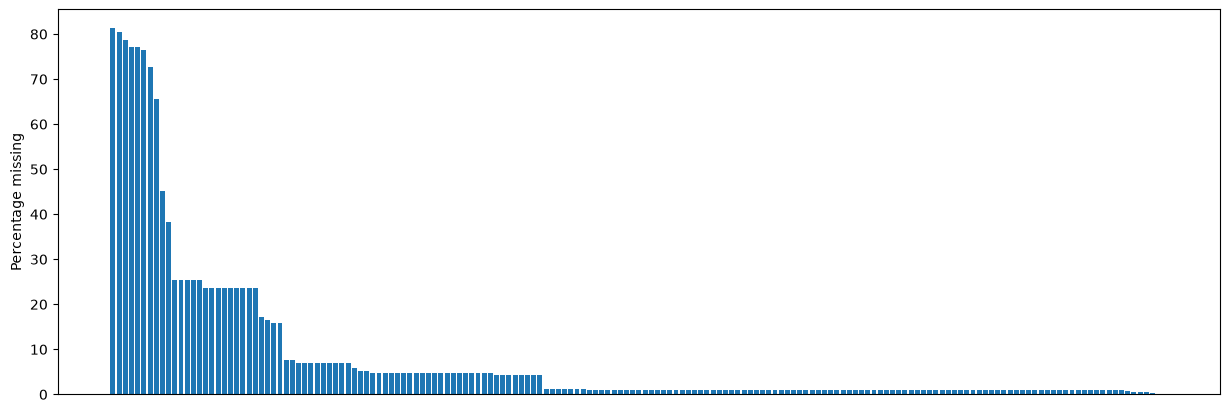

In [10]:
# Plotting Missing values count for each column
# Plotting Missing values count for each column
fig, ax = plt.subplots(figsize=(15,5))

missing = df.isna().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0, ascending = False)

ax.bar(missing.index, missing.values.T[0])
plt.xticks([])
plt.ylabel("Percentage missing")
plt.show()



In [11]:
## Dropping columns which has more than 70% of missing values
dropcols = missing[missing[0]>70]
dropcols

,0
br_000,81.410965
bq_000,80.501824
bp_000,78.794075
cr_000,77.086327
ab_000,77.086327
bo_000,76.533658
bn_000,72.761689


In [12]:
df.drop(list(dropcols.index), axis=1, inplace=True)

In [13]:
# Check shape of the dataset after dropping columns
df.shape

(36188, 164)

In [14]:
missing_values_count= df.isnull().sum()
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

# percent of data that is missing
print(f"Percentage of total missing cells in the data {(total_missing/total_cells) * 100}%")

Percentage of total missing cells in the data 5.37059852747306%


Positive: 1000, Negative: 35188


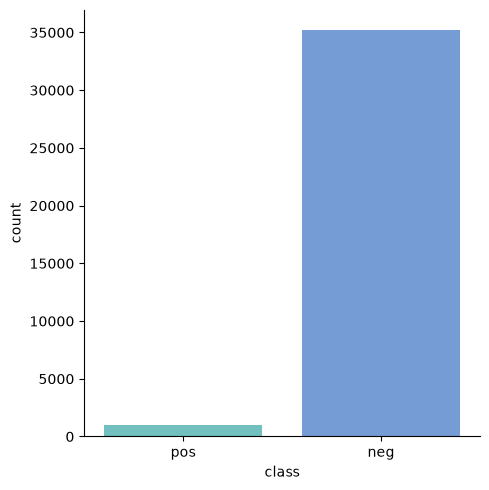

In [15]:
pos = df[df['class']=='pos'].shape[0]
neg = df[df['class']=='neg'].shape[0]
print("Positive: " + str(pos) + ", Negative: " + str(neg))
sns.catplot(data=df, x="class", kind="count", palette="winter_r", alpha=.6)
plt.show()

if we increase pos class -> upsampling
if we decrease neg class -> downsampling

smote is used to handle imbalance data

In [16]:
def evaluate_clf(true, predicted):
    '''
    This function takes in true values and predicted values
    Returns: Accuracy, F1-Score, Precision, Recall, Roc-auc Score
    '''
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [17]:
# Create cost of the model as per data description
def total_cost(y_true, y_pred):
    '''
    This function takes y_ture, y_predicted, and prints Total cost due to misclassification
   
    '''
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    #since fn is more costly than fp, we will give more weightage to fn
    cost = 10*fp + 500*fn
    return cost

In [18]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    cost_list=[]
    models_list = []
    accuracy_list = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)
        train_cost = total_cost(y_train, y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)
        test_cost = total_cost(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))
        print(f'- COST: {train_cost}.')

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        print(f'- COST: {test_cost}.')
        cost_list.append(test_cost)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, cost_list)), columns=['Model Name', 'Cost']).sort_values(by=["Cost"])
        
    return report

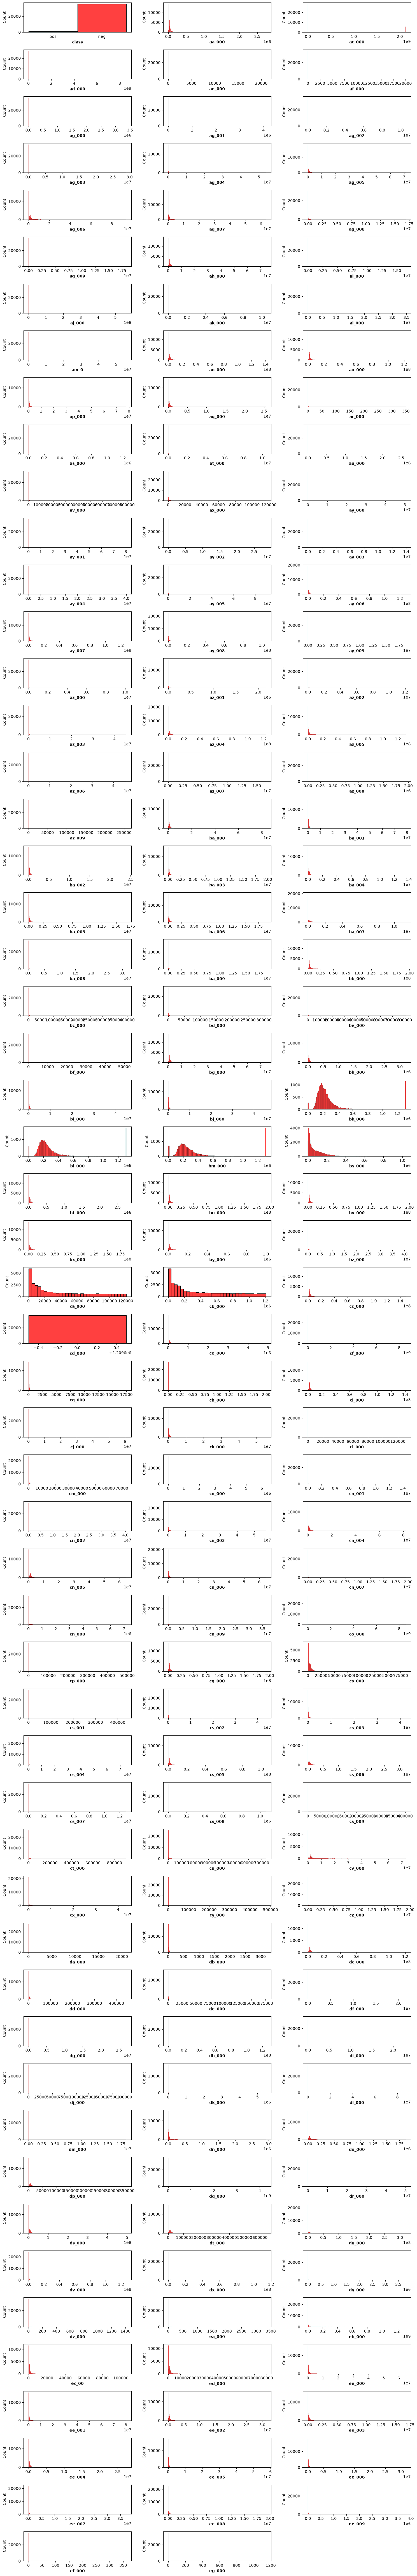

In [19]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

plt.figure(figsize=(15, 100))
for i, col in enumerate(numeric_features):
    plt.subplot(60, 3, i+1)
    sns.histplot(x=df[col], color='red')
    plt.xlabel(col, weight='bold')
    plt.tight_layout()

In [20]:
# Splitting X and y for all Experiments
X= df.drop('class', axis=1)
y = df['class']

In [21]:
y= y.replace({'pos': 1, 'neg': 0})

In [22]:
robustscaler = RobustScaler()
X1 = robustscaler.fit_transform(X)

In [23]:
print(y.head())
print(y.map(type).value_counts())

0    1
1    1
2    1
3    1
4    1
Name: class, dtype: object
class
<class 'int'>    36188
Name: count, dtype: int64


In [24]:
print(y.isnull().sum())

0


In [25]:
print("Shape:", y.shape)
print("Dtype:", y.dtype)
print(type(X1))
print(X1.dtype)
print("Unique values:", np.unique(y)[:20])

Shape: (36188,)
Dtype: object
<class 'numpy.ndarray'>
float64
Unique values: [0 1]


In [26]:
y = y.astype('int64')

print(y.dtype)

int64


In [27]:
from sklearn.utils.multiclass import type_of_target

print(type_of_target(y))

binary


In [28]:
results=[]
# define imputer
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')
strategies = [str(i) for i in [1,3,5,7,9]]
for s in strategies:
    pipeline = Pipeline(steps=[('i', KNNImputer(n_neighbors=int(s))), ('m', LogisticRegression())])
    scores = cross_val_score(pipeline, X1, y, scoring='accuracy', cv=2, n_jobs=-1)
    results.append(scores)
    print('n_neighbors= %s || accuracy (%.4f)' % (s , mean(scores)))

n_neighbors= 1 || accuracy (0.7152)
n_neighbors= 3 || accuracy (0.7157)
n_neighbors= 5 || accuracy (0.7287)
n_neighbors= 7 || accuracy (0.6788)
n_neighbors= 9 || accuracy (0.7056)


In [29]:
#n=5 produces the highest accuracy

num_features = X.select_dtypes(exclude="object").columns

# Fit the KNN imputer with selected K-value
knn_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('RobustScaler', RobustScaler())
])

In [30]:
X_knn =knn_pipeline.fit_transform(X)

In [ ]:
from imblearn.combine import SMOTETomek

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority',n_jobs=-1)   
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_knn, y)

In [32]:
# Dictionary which contains models for experiment
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [33]:
report_knn = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9934
- F1 score: 0.9935
- Precision: 0.9909
- Recall: 0.9960
- Roc Auc Score: 0.9933
- COST: 14650.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9873
- F1 score: 0.9875
- Precision: 0.9840
- Recall: 0.9910
- Roc Auc Score: 0.9873
- COST: 33140.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9833
- F1 score: 0.9833
- Precision: 0.9800
- Recall: 0.9866
- Roc Auc Score: 0.9833
- COST: 193630.
----------------------------------
Model performance for Test set
- Accuracy: 0.9826
- F1 score: 0.9828
- Precision: 0.9795
- Recall: 0.9862
- Roc Auc

In [34]:
report_knn

,Model Name,Cost
5,XGBClassifier,4920
6,CatBoosting Classifier,6520
0,Random Forest,14650
1,Decision Tree,33140
4,K-Neighbors Classifier,47790
2,Gradient Boosting,50460
7,AdaBoost Classifier,100150
3,Logistic Regression,247380


For experiment 1: using KNN imputer XGBoost gives the least cost thus its the best model

### Experiment 2: using Median

In [35]:
num_features = X.select_dtypes(exclude="object").columns

# Fit the Simple imputer with strategy median
median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('RobustScaler', RobustScaler())
])

In [36]:
# Fit X with median_pipeline
X_median = median_pipeline.fit_transform(X)

In [37]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority')
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_median, y)

In [38]:
report_median = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9910
- F1 score: 0.9911
- Precision: 0.9853
- Recall: 0.9970
- Roc Auc Score: 0.9910
- COST: 11550.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9854
- F1 score: 0.9856
- Precision: 0.9789
- Recall: 0.9924
- Roc Auc Score: 0.9853
- COST: 28510.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9840
- F1 score: 0.9840
- Precision: 0.9813
- Recall: 0.9867
- Roc Auc Score: 0.9840
- COST: 190760.
----------------------------------
Model performance for Test set
- Accuracy: 0.9809
- F1 score: 0.9812
- Precision: 0.9755
- Recall: 0.9868
- Roc Auc

In [39]:
report_median

,Model Name,Cost
6,CatBoosting Classifier,5270
5,XGBClassifier,6100
0,Random Forest,11550
1,Decision Tree,28510
2,Gradient Boosting,48250
4,K-Neighbors Classifier,54430
7,AdaBoost Classifier,89540
3,Logistic Regression,307670


- For the Experiment 2: Simple imputer with median strategy has Catboost classifier as the best Model
- Proceeding with further experiments 

### Experiment: 3 = MICE for Imputing Null values

In [43]:
import miceforest as mf

X_mice = X.copy()
kernel = mf.ImputationKernel(
  X_mice,
  save_all_iterations_data=True,
  random_state=1989
)# Run the MICE algorithm for 3 iterations kernel.mice(3)

In [44]:
X_mice = kernel.complete_data()

In [45]:
# fit robust scaler
mice_pipeline = Pipeline(steps=[
    ('RobustScaler', RobustScaler())
])

In [46]:
X_mice= mice_pipeline.fit_transform(X_mice)

In [47]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority', n_jobs=-1 )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_mice, y)

In [48]:
report_mice = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9885
- F1 score: 0.9886
- Precision: 0.9817
- Recall: 0.9956
- Roc Auc Score: 0.9885
- COST: 16800.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9815
- F1 score: 0.9816
- Precision: 0.9771
- Recall: 0.9862
- Roc Auc Score: 0.9815
- COST: 50120.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9848
- F1 score: 0.9848
- Precision: 0.9819
- Recall: 0.9878
- Roc Auc Score: 0.9848
- COST: 176600.
----------------------------------
Model performance for Test set
- Accuracy: 0.9803
- F1 score: 0.9805
- Precision: 0.9740
- Recall: 0.9870
- Roc Auc

In [49]:
report_mice

,Model Name,Cost
5,XGBClassifier,9170
6,CatBoosting Classifier,15190
0,Random Forest,16800
2,Gradient Boosting,47350
1,Decision Tree,50120
4,K-Neighbors Classifier,54870
7,AdaBoost Classifier,91490
3,Logistic Regression,163560


- For the Experiment 3: Mice imputer has XGBoost classifier as the best Model
- Proceeding with further experiments 

### Experiment: 4 = Simple Imputer with Strategy Constant 

In [50]:
# Create a pipeline with simple imputer with strategy constant and fill value 0
constant_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('RobustScaler', RobustScaler())
])

In [51]:
X_const =constant_pipeline.fit_transform(X)

In [52]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority', n_jobs=-1 )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_const, y)

In [53]:
report_const = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9930
- F1 score: 0.9931
- Precision: 0.9893
- Recall: 0.9969
- Roc Auc Score: 0.9930
- COST: 11760.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9879
- F1 score: 0.9880
- Precision: 0.9826
- Recall: 0.9935
- Roc Auc Score: 0.9879
- COST: 24240.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9830
- F1 score: 0.9830
- Precision: 0.9803
- Recall: 0.9857
- Roc Auc Score: 0.9830
- COST: 205550.
----------------------------------
Model performance for Test set
- Accuracy: 0.9806
- F1 score: 0.9807
- Precision: 0.9770
- Recall: 0.9845
- Roc Auc

In [54]:
report_const

,Model Name,Cost
5,XGBClassifier,2420
6,CatBoosting Classifier,4490
0,Random Forest,11760
1,Decision Tree,24240
4,K-Neighbors Classifier,43200
2,Gradient Boosting,56130
7,AdaBoost Classifier,92210
3,Logistic Regression,115230


## Experiment: 5 = Simple Imputer with Strategy Mean 

- Another strategy which can be used is replacing missing values with mean
- Here we replace the missing values with the mean of the column

In [55]:
# Create a pipeline with Simple imputer with strategy mean
mean_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='mean')),
    ('RobustScaler', RobustScaler())
])

In [56]:
X_mean = mean_pipeline.fit_transform(X)

In [57]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority' , n_jobs=-1)
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_mean, y)

In [58]:
# Training all models
report_mean = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9937
- F1 score: 0.9937
- Precision: 0.9904
- Recall: 0.9970
- Roc Auc Score: 0.9938
- COST: 11170.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9876
- F1 score: 0.9875
- Precision: 0.9849
- Recall: 0.9900
- Roc Auc Score: 0.9876
- COST: 35550.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9857
- F1 score: 0.9858
- Precision: 0.9828
- Recall: 0.9889
- Roc Auc Score: 0.9857
- COST: 161370.
----------------------------------
Model performance for Test set
- Accuracy: 0.9866
- F1 score: 0.9865
- Precision: 0.9836
- Recall: 0.9893
- Roc Auc

In [59]:
report_mean

,Model Name,Cost
5,XGBClassifier,1930
6,CatBoosting Classifier,4980
0,Random Forest,11170
1,Decision Tree,35550
2,Gradient Boosting,38140
4,K-Neighbors Classifier,44770
7,AdaBoost Classifier,91120
3,Logistic Regression,305150


### Experiment: 6 = Principle component analysis with imputing median

In [60]:
from sklearn.decomposition import PCA

In [61]:
pca_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('RobustScaler', RobustScaler())
])

In [62]:
X_pca = pca_pipeline.fit_transform(X)

In [63]:
#Applying PCA
from sklearn.decomposition import PCA
var_ratio={}
for n in range(2,150):
    pc=PCA(n_components=n)
    df_pca=pc.fit(X_pca)
    var_ratio[n]=sum(df_pca.explained_variance_ratio_)

<Axes: >

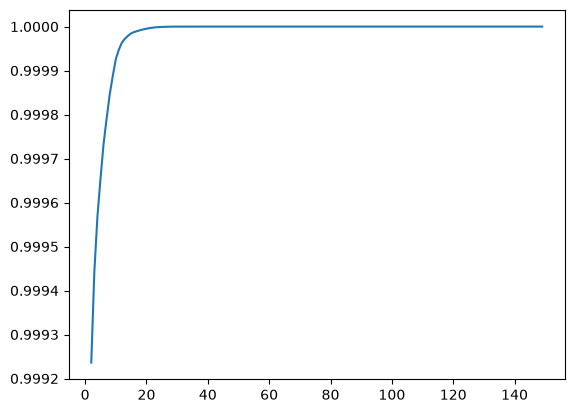

In [64]:
pd.Series(var_ratio).plot()

<Figure size 500x500 with 0 Axes>

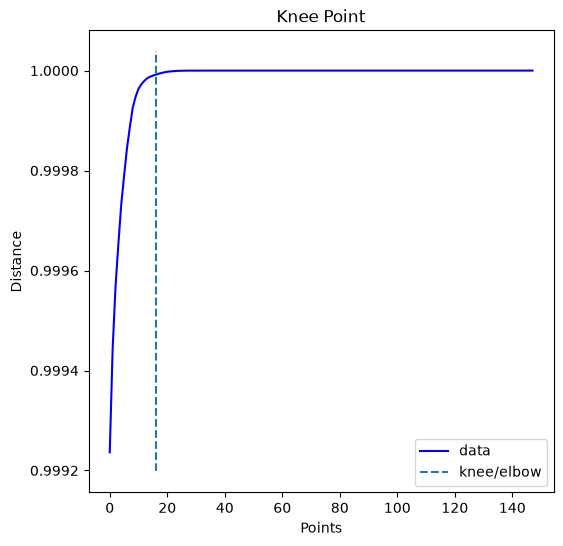

Knee Locator k = 18


In [66]:
from kneed import KneeLocator

i = np.arange(len(var_ratio))
variance_ratio= list(var_ratio.values())
components=  list(var_ratio.keys())
knee = KneeLocator(i, variance_ratio, S=1, curve='concave', interp_method='polynomial')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()
k= components[knee.knee]
print('Knee Locator k =', k)

In [67]:
# Reducing the dimensions of the data 
pca_final=PCA(n_components=18,random_state=42).fit(X_res)

reduced=pca_final.fit_transform(X_pca)

In [68]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority', n_jobs=-1)
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(reduced, y)

In [70]:
# Training all models
report_pca = evaluate_models(X_res,y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 0.9987
- F1 score: 0.9987
- Precision: 1.0000
- Recall: 0.9974
- Roc Auc Score: 0.9987
- COST: 36000.
----------------------------------
Model performance for Test set
- Accuracy: 0.9825
- F1 score: 0.9827
- Precision: 0.9774
- Recall: 0.9881
- Roc Auc Score: 0.9824
- COST: 43610.


Decision Tree
Model performance for Training set
- Accuracy: 0.9987
- F1 score: 0.9987
- Precision: 1.0000
- Recall: 0.9974
- Roc Auc Score: 0.9987
- COST: 36000.
----------------------------------
Model performance for Test set
- Accuracy: 0.9708
- F1 score: 0.9712
- Precision: 0.9664
- Recall: 0.9760
- Roc Auc Score: 0.9708
- COST: 86890.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9421
- F1 score: 0.9418
- Precision: 0.9439
- Recall: 0.9398
- Roc Auc Score: 0.9421
- COST: 855600.
----------------------------------
Model performance for Test set
- Accuracy: 0.9386
- F1 score: 0.9391
- Precision: 0.9397
- Recall: 0.9386
-

In [71]:
report_pca

,Model Name,Cost
0,Random Forest,43610
5,XGBClassifier,62580
6,CatBoosting Classifier,70640
4,K-Neighbors Classifier,86510
1,Decision Tree,86890
2,Gradient Boosting,220750
7,AdaBoost Classifier,327640
3,Logistic Regression,708920


## Final Model

In [74]:
from prettytable import PrettyTable

pt=PrettyTable()
pt.field_names=["Model","Imputation_method","Total_cost"]
pt.add_row(["XGBClassifier","Simple Imputer-Mean","1930"])
pt.add_row(["XGBClassifier","Simple Imputer-Constant","2420"])
pt.add_row(["XGBClassifier","Knn-Imputer","4920"])
pt.add_row(["CatBoostClassifier","Median","5270"])
pt.add_row(["XGBClassifier","Mice","9170"])
pt.add_row(["Random Forest","PCA","43610"])
print(pt)

+--------------------+-------------------------+------------+
|       Model        |    Imputation_method    | Total_cost |
+--------------------+-------------------------+------------+
|   XGBClassifier    |   Simple Imputer-Mean   |    1930    |
|   XGBClassifier    | Simple Imputer-Constant |    2420    |
|   XGBClassifier    |       Knn-Imputer       |    4920    |
| CatBoostClassifier |          Median         |    5270    |
|   XGBClassifier    |           Mice          |    9170    |
|   Random Forest    |           PCA           |   43610    |
+--------------------+-------------------------+------------+


- From the final report we can see than XGBClassifier with Simple imputer with strategy Mean has performed the best with cost of 1930

In [75]:
final_model = XGBClassifier()

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority' , n_jobs=-1)
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_mean, y)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)

final_model = final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [77]:
print("Final XGBoost Classifier Accuracy Score (Train) :", final_model.score(X_train,y_train))
print("Final XGBoost Classifier Accuracy Score (Test) :", accuracy_score(y_pred,y_test))

Final XGBoost Classifier Accuracy Score (Train) : 0.9999821810406272
Final XGBoost Classifier Accuracy Score (Test) : 0.9967213114754099


In [78]:
print("Final XGBoost Classifier Cost Metric(Test) :", total_cost(y_test, y_pred))

Final XGBoost Classifier Cost Metric(Test) : 1930


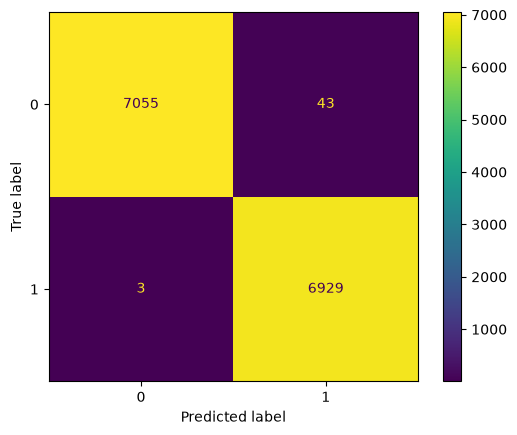

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay
#plots Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## The best Model is XGBoost Classifier with 99.6% accuracy and cost of 1930